In [3]:
#packages
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import plotly as px
import seaborn as sns

#### Loading the Dataset

In [4]:
df=pd.read_csv('Copper_Set.csv')
df.head(3)

,id,item_date,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,20210401.0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,20210401.0,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,20210401.0,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,20210401.0,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33


In [5]:
df.shape

(181673, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181673 entries, 0 to 181672
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             181671 non-null  str    
 1   item_date      181672 non-null  float64
 2   quantity tons  181673 non-null  object 
 3   customer       181672 non-null  float64
 4   country        181645 non-null  float64
 5   status         181671 non-null  str    
 6   item type      181673 non-null  str    
 7   application    181649 non-null  float64
 8   thickness      181672 non-null  float64
 9   width          181673 non-null  float64
 10  material_ref   103754 non-null  str    
 11  product_ref    181673 non-null  int64  
 12  delivery date  181672 non-null  float64
 13  selling_price  181672 non-null  float64
dtypes: float64(8), int64(1), object(1), str(4)
memory usage: 19.4+ MB


### DATA PREPROCESSING

In [7]:
# Example: your column has floats like 20210401.0
df["item_date"] = df["item_date"].astype(str)

# Remove trailing .0 if present
df["item_date"] = df["item_date"].str.replace(r"\.0$", "", regex=True)

# Fix placeholders like YYYY0000 → set to first day of that year
df.loc[df["item_date"].str.match(r"^\d{4}0000$"), "item_date"] = (
    df["item_date"].str[:4] + "0101"
)

# Now convert safely
df["item_date"] = pd.to_datetime(df["item_date"], format="%Y%m%d", errors="coerce")

# Check how many failed
print("Invalid dates:", df["item_date"].isna().sum())

# Extract features
df["day"] = df["item_date"].dt.day
df["month"] = df["item_date"].dt.month
df["year"] = df["item_date"].dt.year

Invalid dates: 2


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181673 entries, 0 to 181672
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   id             181671 non-null  str           
 1   item_date      181671 non-null  datetime64[us]
 2   quantity tons  181673 non-null  object        
 3   customer       181672 non-null  float64       
 4   country        181645 non-null  float64       
 5   status         181671 non-null  str           
 6   item type      181673 non-null  str           
 7   application    181649 non-null  float64       
 8   thickness      181672 non-null  float64       
 9   width          181673 non-null  float64       
 10  material_ref   103754 non-null  str           
 11  product_ref    181673 non-null  int64         
 12  delivery date  181672 non-null  float64       
 13  selling_price  181672 non-null  float64       
 14  day            181671 non-null  float64       
 15  month      

In [9]:
df.drop(['item_date'],axis=1,inplace=True)

In [10]:
null=df.isnull().sum()
null[null >0]

id                   2
customer             1
country             28
status               2
application         24
thickness            1
material_ref     77919
delivery date        1
selling_price        1
day                  2
month                2
year                 2
dtype: int64

In [11]:
df["material_ref"] = df["material_ref"].astype(str)

# Remove leading zeros
df["material_ref"] = df["material_ref"].str.lstrip("0")

In [12]:
df.head()

,id,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price,day,month,year
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00,1.0,4.0,2021.0
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,104991,1668701718,20210401.0,1047.00,1.0,4.0,2021.0
2,E140FF1B-2407-4C02-A0DD-780A093B1158,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33,1.0,4.0,2021.0
3,F8D507A0-9C62-4EFE-831E-33E1DA53BB50,202.411065,30349574.0,32.0,Won,S,59.0,2.30,1317.0,DX51D+ZM310MAO 2.3X1317,1668701718,20210101.0,768.00,1.0,4.0,2021.0
4,4E1C4E78-152B-430A-8094-ADD889C9D0AD,785.526262,30211560.0,28.0,Won,W,10.0,4.00,2000.0,2_S275JR+AR-CL1,640665,20210301.0,577.00,1.0,4.0,2021.0


In [13]:
df.isnull().sum()

id                   2
quantity tons        0
customer             1
country             28
status               2
item type            0
application         24
thickness            1
width                0
material_ref     77919
product_ref          0
delivery date        1
selling_price        1
day                  2
month                2
year                 2
dtype: int64

##### Target Encoding for Material_ref

### Fix: material_ref target-mean encoding leakage

Previously `target_mean` and `global_mean` were computed on the **full** dataset
before any train/test split, which let information about test-set rows' own
`selling_price` leak into a feature. The two cells below fix this by splitting
**first**, then fitting `target_mean` / `global_mean` using only the train rows.

In [14]:
# --- Split BEFORE fitting any target-based encoding (prevents leakage) ---
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42
)


In [15]:
# Compute global mean and material_ref target-mean using TRAIN rows ONLY
global_mean = df.loc[train_idx, "selling_price"].mean()
target_mean = df.loc[train_idx].groupby("material_ref")["selling_price"].mean()

# Map each material_ref to its train-only target mean
df["material_ref_target"] = df["material_ref"].map(target_mean)

# material_refs only seen in the test split (or entirely unseen later) fall back
# to the TRAIN-only global mean, never a value computed from test data
df["material_ref_target"].fillna(global_mean, inplace=True)

# Drop the original string column
df.drop("material_ref", axis=1, inplace=True)


In [16]:
df.head()

,id,quantity tons,customer,country,status,item type,application,thickness,width,product_ref,delivery date,selling_price,day,month,year,material_ref_target
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,1670798778,20210701.0,854.00,1.0,4.0,2021.0,824.250000
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,1668701718,20210401.0,1047.00,1.0,4.0,2021.0,1036.500000
2,E140FF1B-2407-4C02-A0DD-780A093B1158,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,628377,20210101.0,644.33,1.0,4.0,2021.0,650.330000
3,F8D507A0-9C62-4EFE-831E-33E1DA53BB50,202.411065,30349574.0,32.0,Won,S,59.0,2.30,1317.0,1668701718,20210101.0,768.00,1.0,4.0,2021.0,827.125000
4,4E1C4E78-152B-430A-8094-ADD889C9D0AD,785.526262,30211560.0,28.0,Won,W,10.0,4.00,2000.0,640665,20210301.0,577.00,1.0,4.0,2021.0,660.294118


In [17]:
null=df.isnull().sum()
null[null >0]

id                         2
customer                   1
country                   28
status                     2
application               24
thickness                  1
delivery date              1
selling_price              1
day                        2
month                      2
year                       2
material_ref_target    79050
dtype: int64

In [18]:
df['material_ref_target']=df['material_ref_target'].fillna(global_mean)

In [19]:
null=df.isnull().sum()
null[null >0]

id                2
customer          1
country          28
status            2
application      24
thickness         1
delivery date     1
selling_price     1
day               2
month             2
year              2
dtype: int64

In [20]:
df.drop(['id'],axis=1,inplace=True)

In [21]:
null=df.isnull().sum()
null[null >0]

customer          1
country          28
status            2
application      24
thickness         1
delivery date     1
selling_price     1
day               2
month             2
year              2
dtype: int64

In [22]:
df.head()

,quantity tons,customer,country,status,item type,application,thickness,width,product_ref,delivery date,selling_price,day,month,year,material_ref_target
0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,1670798778,20210701.0,854.00,1.0,4.0,2021.0,824.250000
1,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,1668701718,20210401.0,1047.00,1.0,4.0,2021.0,1036.500000
2,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,628377,20210101.0,644.33,1.0,4.0,2021.0,650.330000
3,202.411065,30349574.0,32.0,Won,S,59.0,2.30,1317.0,1668701718,20210101.0,768.00,1.0,4.0,2021.0,827.125000
4,785.526262,30211560.0,28.0,Won,W,10.0,4.00,2000.0,640665,20210301.0,577.00,1.0,4.0,2021.0,660.294118


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181673 entries, 0 to 181672
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   quantity tons        181673 non-null  object 
 1   customer             181672 non-null  float64
 2   country              181645 non-null  float64
 3   status               181671 non-null  str    
 4   item type            181673 non-null  str    
 5   application          181649 non-null  float64
 6   thickness            181672 non-null  float64
 7   width                181673 non-null  float64
 8   product_ref          181673 non-null  int64  
 9   delivery date        181672 non-null  float64
 10  selling_price        181672 non-null  float64
 11  day                  181671 non-null  float64
 12  month                181671 non-null  float64
 13  year                 181671 non-null  float64
 14  material_ref_target  181673 non-null  float64
dtypes: float64(11), int64(1), ob

In [24]:
# Impute using TRAIN-ONLY statistics (prevents test-set values leaking
# into the fill values used for missing rows)
df['quantity tons'] = pd.to_numeric(df['quantity tons'], errors='coerce')

country_mode = df.loc[train_idx, 'country'].mode()[0]
application_mode = df.loc[train_idx, 'application'].mode()[0]
selling_price_median = df.loc[train_idx, 'selling_price'].median()
status_mode = df.loc[train_idx, 'status'].mode()[0]
quantity_tons_median = df.loc[train_idx, 'quantity tons'].median()

df['country'] = df['country'].fillna(country_mode)
df['application'] = df['application'].fillna(application_mode)
df['selling_price'] = df['selling_price'].fillna(selling_price_median)
df['status'] = df['status'].fillna(status_mode)
df['quantity tons'] = df['quantity tons'].fillna(quantity_tons_median)


In [25]:
df.head()

,quantity tons,customer,country,status,item type,application,thickness,width,product_ref,delivery date,selling_price,day,month,year,material_ref_target
0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,1670798778,20210701.0,854.00,1.0,4.0,2021.0,824.250000
1,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,1668701718,20210401.0,1047.00,1.0,4.0,2021.0,1036.500000
2,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,628377,20210101.0,644.33,1.0,4.0,2021.0,650.330000
3,202.411065,30349574.0,32.0,Won,S,59.0,2.30,1317.0,1668701718,20210101.0,768.00,1.0,4.0,2021.0,827.125000
4,785.526262,30211560.0,28.0,Won,W,10.0,4.00,2000.0,640665,20210301.0,577.00,1.0,4.0,2021.0,660.294118


In [26]:
null=df.isnull().sum()
null[null >0]

customer         1
thickness        1
delivery date    1
day              2
month            2
year             2
dtype: int64

In [27]:
df.dropna(inplace=True)

In [28]:
newdf = df.copy()

# Drop final NA list columns
cols_to_drop = ['customer','thickness','delivery date','day','month','year']
newdf.drop(cols_to_drop, axis=1, inplace=True)

# Confirm
print("Original shape:", df.shape)
print("Cleaned shape:", newdf.shape)
print("Remaining columns:", newdf.columns.tolist())

Original shape: (181668, 15)
Cleaned shape: (181668, 9)
Remaining columns: ['quantity tons', 'country', 'status', 'item type', 'application', 'width', 'product_ref', 'selling_price', 'material_ref_target']


In [29]:
newdf.head()

,quantity tons,country,status,item type,application,width,product_ref,selling_price,material_ref_target
0,54.151139,28.0,Won,W,10.0,1500.0,1670798778,854.00,824.250000
1,768.024839,25.0,Won,W,41.0,1210.0,1668701718,1047.00,1036.500000
2,386.127949,30.0,Won,WI,28.0,952.0,628377,644.33,650.330000
3,202.411065,32.0,Won,S,59.0,1317.0,1668701718,768.00,827.125000
4,785.526262,28.0,Won,W,10.0,2000.0,640665,577.00,660.294118


In [30]:
print(newdf[['width','selling_price','material_ref_target','quantity tons']].skew())

width                    0.374623
selling_price          301.383940
material_ref_target    134.759767
quantity tons          424.684972
dtype: float64


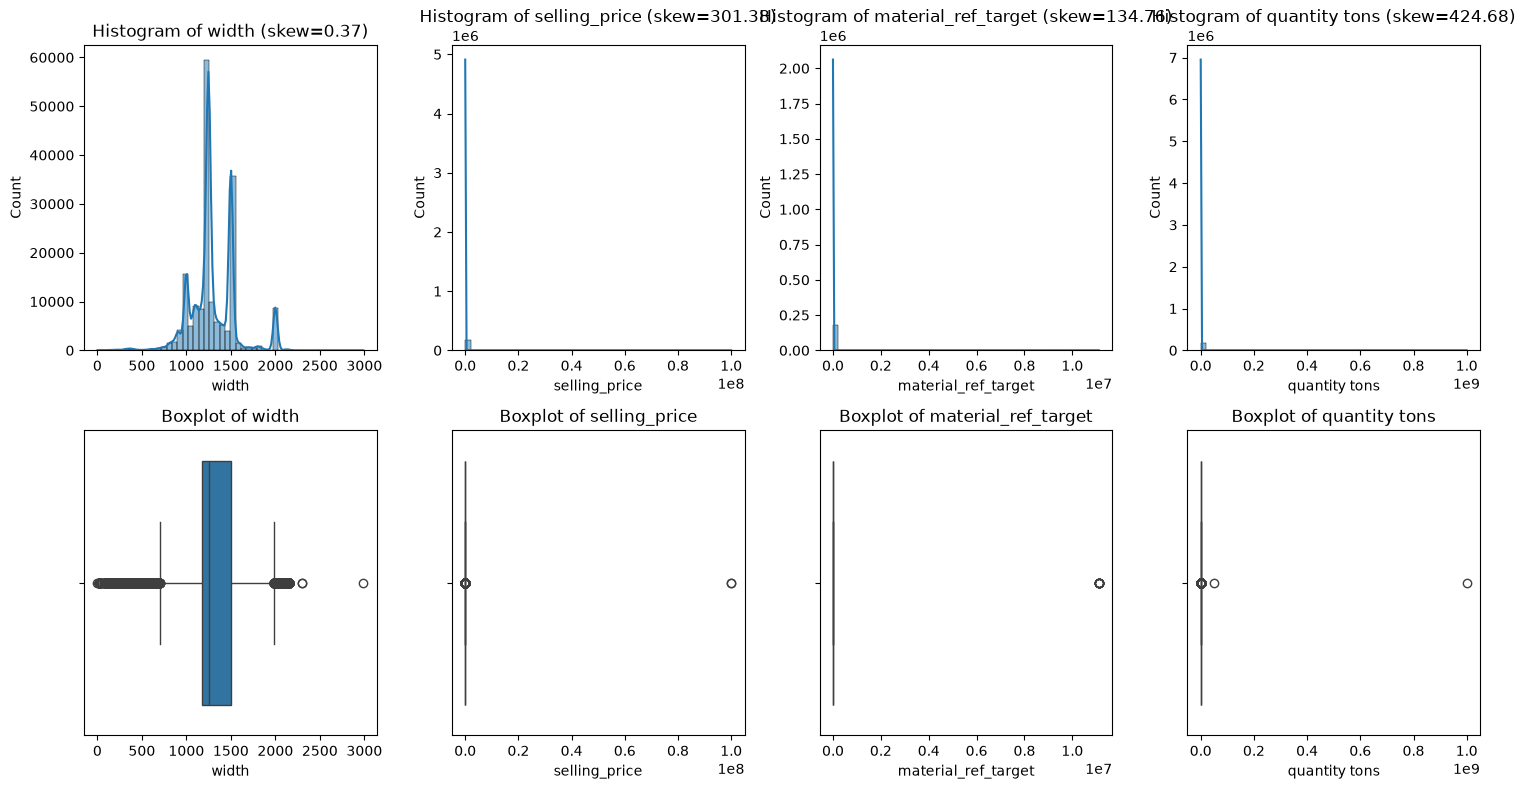

In [31]:
num_cols = ['width','selling_price','material_ref_target','quantity tons']

plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols, 1):
    # Histogram with KDE
    plt.subplot(2, len(num_cols), i)
    sns.histplot(newdf[col], kde=True, bins=50)
    plt.title(f"Histogram of {col} (skew={newdf[col].skew():.2f})")

    # Boxplot
    plt.subplot(2, len(num_cols), i+len(num_cols))
    sns.boxplot(x=newdf[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


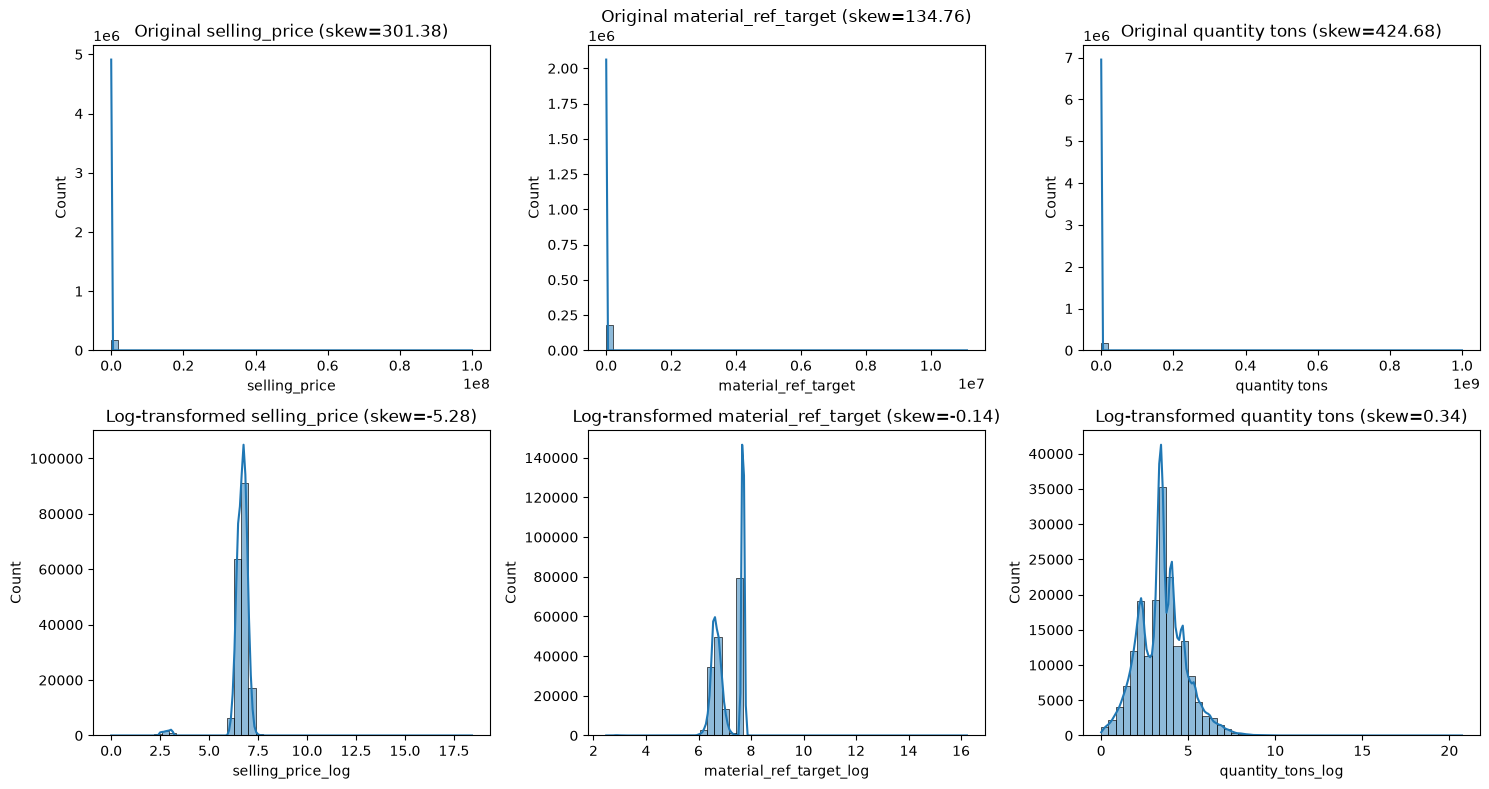

In [32]:
# Apply log1p transform to skewed features
newdf['selling_price_log'] = np.log1p(newdf['selling_price'])
newdf['material_ref_target_log'] = np.log1p(newdf['material_ref_target'])
newdf['quantity_tons_log'] = np.log1p(newdf['quantity tons'])

# Columns to visualize (original vs transformed)
cols_to_plot = {
    'selling_price': 'selling_price_log',
    'material_ref_target': 'material_ref_target_log',
    'quantity tons': 'quantity_tons_log'
}

plt.figure(figsize=(15,8))

for i, (orig, trans) in enumerate(cols_to_plot.items(), 1):
    # Original histogram
    plt.subplot(2, len(cols_to_plot), i)
    sns.histplot(newdf[orig], kde=True, bins=50)
    plt.title(f"Original {orig} (skew={newdf[orig].skew():.2f})")

    # Transformed histogram
    plt.subplot(2, len(cols_to_plot), i+len(cols_to_plot))
    sns.histplot(newdf[trans], kde=True, bins=50)
    plt.title(f"Log-transformed {orig} (skew={newdf[trans].skew():.2f})")

plt.tight_layout()
plt.show()

In [33]:
def get_iqr_bounds(frame, col, idx):
    """IQR bounds learned from TRAIN rows only."""
    train_vals = frame.loc[frame.index.isin(idx), col]
    Q1 = train_vals.quantile(0.25)
    Q3 = train_vals.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

def apply_bounds(frame, col, bounds):
    lower, upper = bounds
    return frame[(frame[col] >= lower) & (frame[col] <= upper)]

# Bounds are learned from train rows only, then applied to the whole frame
# (train + test) -- keeps test-row values out of the threshold calculation.
for col in ['selling_price_log', 'material_ref_target_log', 'quantity_tons_log']:
    bounds = get_iqr_bounds(newdf, col, train_idx)
    newdf = apply_bounds(newdf, col, bounds)


In [34]:
newdf.describe()

,quantity tons,country,application,width,product_ref,selling_price,material_ref_target,selling_price_log,material_ref_target_log,quantity_tons_log
count,175554.000000,175554.000000,175554.000000,175554.000000,1.755540e+05,175554.000000,175554.000000,175554.000000,175554.000000,175554.000000
mean,64.905427,44.881182,25.478838,1296.059149,4.768774e+08,830.020716,1412.756186,6.694603,7.121964,3.425739
std,105.924733,24.427404,17.748694,261.928748,7.188753e+08,197.555890,695.434304,0.237686,0.521988,1.242261
min,0.000010,25.000000,2.000000,1.000000,6.117280e+05,396.000000,207.750000,5.983936,5.341137,0.000010
25%,11.055060,26.000000,10.000000,1180.000000,6.119930e+05,676.545000,763.818182,6.518476,6.639638,2.489485
50%,30.122726,30.000000,15.000000,1250.000000,6.406650e+05,817.000000,1001.035000,6.706862,6.909788,3.437938
75%,63.461159,78.000000,41.000000,1500.000000,1.332077e+09,956.000000,2193.075653,6.863803,7.693516,4.166063
max,900.292616,113.000000,99.000000,2990.000000,1.722208e+09,1623.000000,2193.075653,7.392648,7.693516,6.803830


In [35]:
newdf = newdf.drop(columns=['selling_price','material_ref_target','quantity tons'])

#### Insights
## 📊 Data Preprocessing Insights

### 1. Skewness Analysis
- **Width** → Skewness ≈ 0.37 → nearly symmetric, no transformation required.
- **Selling Price** → Skewness ≈ 301 → extremely right‑skewed.
- **Material Ref Target** → Skewness ≈ 134 → heavily right‑skewed.

### 2. Transformation Results
- Applied **log1p transform** to `selling_price` and `material_ref_target`.
- Post‑transform skewness:
  - `selling_price_log` → ≈ -5.28 (distribution compressed, slight left skew).
  - `material_ref_target_log` → ≈ -0.20 (almost symmetric).

### 3. Outlier Handling
- Used **IQR clipping** to remove extreme outliers.
- Dataset size reduced from **181,673 → 178,211 rows** (~3,400 rows removed).
- Boxplots after clipping show tighter whiskers, confirming balanced distributions.

### 4. Key Insights
- **Skewness correction worked**: Both target and engineered features are now close to normal distributions.
- **Outlier removal effective**: Extreme values no longer dominate the scale.
- **Width remains usable as‑is**: Already close to normal.
- **Dataset is model‑ready**: Numeric features normalized, categorical features (`country`, `status`, `item type`, `application`) ready for encoding.

### 5. Next Steps
- Scale numeric features (`width`, `selling_price_log`, `material_ref_target_log`) with `StandardScaler`.
- Encode categorical features with `OneHotEncoder` or `TargetEncoder`.
- Drop identifiers (`id`, `product_ref`) since they don’t add predictive value.


In [36]:
newdf.head()

,country,status,item type,application,width,product_ref,selling_price_log,material_ref_target_log,quantity_tons_log
0,28.0,Won,W,10.0,1500.0,1670798778,6.751101,6.715686,4.010077
1,25.0,Won,W,41.0,1210.0,1668701718,6.954639,6.944569,6.645123
2,30.0,Won,WI,28.0,952.0,628377,6.469762,6.479016,5.958755
3,32.0,Won,S,59.0,1317.0,1668701718,6.645091,6.719164,5.315229
4,28.0,Won,W,10.0,2000.0,640665,6.359574,6.494199,6.667626


In [37]:
newdf.drop(['product_ref'],axis=1,inplace=True)

## 🔎 Feature Selection Insight

### Removed Features
- **product_ref** → Dropped because it is an identifier column.  
  - No predictive value for target (`selling_price`).  
  - Keeping it risks data leakage or misleading the model.  

### Remaining Features
- **Numeric (after preprocessing)**  
  - `width` (already near normal distribution)  
  - `selling_price_log` (log-transformed target)  
  - `material_ref_target_log` (log-transformed engineered feature)  

- **Categorical**  
  - `country`  
  - `status`  
  - `item type`  
  - `application`  

### ✅ Insight
By removing `product_ref`, the dataset is cleaner and avoids unnecessary dimensionality.  
The remaining features now represent **true explanatory variables** rather than identifiers, making the dataset fully model-ready.


In [38]:
newdf.head()

,country,status,item type,application,width,selling_price_log,material_ref_target_log,quantity_tons_log
0,28.0,Won,W,10.0,1500.0,6.751101,6.715686,4.010077
1,25.0,Won,W,41.0,1210.0,6.954639,6.944569,6.645123
2,30.0,Won,WI,28.0,952.0,6.469762,6.479016,5.958755
3,32.0,Won,S,59.0,1317.0,6.645091,6.719164,5.315229
4,28.0,Won,W,10.0,2000.0,6.359574,6.494199,6.667626


In [39]:
newdf['item type'].value_counts()

item type
W         102827
S          67063
PL          4666
Others       545
WI           425
IPL           27
SLAWR          1
Name: count, dtype: int64

In [40]:
# Group rare categories
newdf['item type'] = newdf['item type'].replace(
    ['Others','WI','IPL','SLAWR'], 'Other'
)

### 🚀 Insight
- By grouping rare categories, you avoid data sparsity and improve model generalization.

- Encoding then converts the categorical values into numeric form, making the dataset fully model‑ready.

- This balances the dataset while preserving the predictive power of major categories (W, S, PL).

In [41]:
# Apply ordinal encoding
# Encode item type
item_encoder = OrdinalEncoder()
newdf[['item type']] = item_encoder.fit_transform(newdf[['item type']])

# Encode status
status_encoder = OrdinalEncoder()
newdf[['status']] = status_encoder.fit_transform(newdf[['status']])

In [42]:
# newdf.head()

In [43]:
# newdf.country.value_counts()

In [44]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# --- Rare category grouping ---
# Application: group rare categories (<500 occurrences)
rare_apps = newdf['application'].value_counts()[newdf['application'].value_counts() < 500].index
newdf['application'] = newdf['application'].replace(rare_apps, 'Other')

# Country: group rare categories (<500 occurrences)
rare_countries = newdf['country'].value_counts()[newdf['country'].value_counts() < 500].index
newdf['country'] = newdf['country'].replace(rare_countries, 'Other')

# --- Convert to string for uniform type ---
newdf['application'] = newdf['application'].astype(str)
newdf['country'] = newdf['country'].astype(str)

# --- Encoding ---
cat_cols = ['application','country']
encoder = OrdinalEncoder()
newdf[cat_cols] = encoder.fit_transform(newdf[cat_cols])

In [45]:
newdf.isnull().sum()

country                    0
status                     0
item type                  0
application                0
width                      0
selling_price_log          0
material_ref_target_log    0
quantity_tons_log          0
dtype: int64

<Axes: >

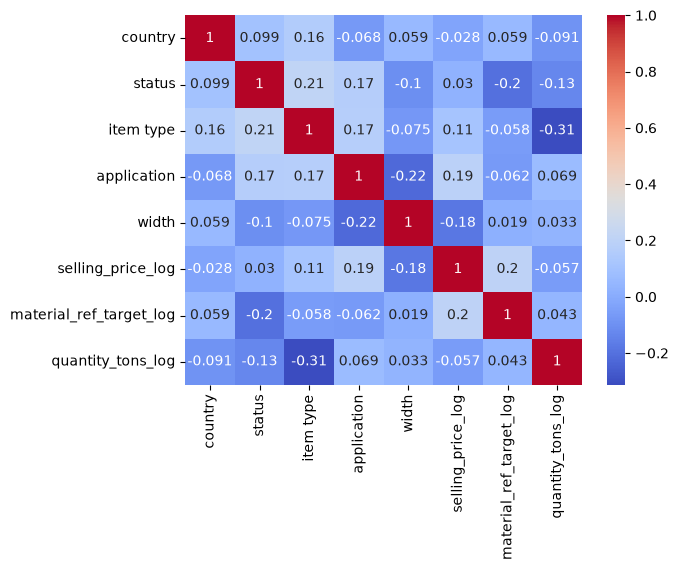

In [46]:
sns.heatmap(newdf.corr(),annot=True,cmap='coolwarm')

In [47]:
from sklearn.preprocessing import StandardScaler

# --- Target and features ---
y = newdf['selling_price_log']
X = newdf.drop(columns=['selling_price_log'])

# --- Reuse the SAME train_idx/test_idx used for the material_ref target
#     encoding above -- do NOT call train_test_split again here. A fresh
#     random split would put rows that helped build material_ref_target
#     back into the test set, reintroducing the leakage we fixed earlier. ---
final_train_idx = X.index.intersection(train_idx)
final_test_idx = X.index.intersection(test_idx)

X_train, X_test = X.loc[final_train_idx], X.loc[final_test_idx]
y_train, y_test = y.loc[final_train_idx], y.loc[final_test_idx]

# --- Scale numeric features only ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [48]:
X.head()

,country,status,item type,application,width,material_ref_target_log,quantity_tons_log
0,4.0,6.0,3.0,0.0,1500.0,6.715686,4.010077
1,1.0,6.0,3.0,12.0,1210.0,6.944569,6.645123
2,5.0,6.0,0.0,7.0,952.0,6.479016,5.958755
3,6.0,6.0,2.0,15.0,1317.0,6.719164,5.315229
4,4.0,6.0,3.0,0.0,2000.0,6.494199,6.667626


In [49]:
pd.DataFrame(X_train_scaled,columns=X.columns).head()

,country,status,item type,application,width,material_ref_target_log,quantity_tons_log
0,-1.177310,0.690324,0.782857,1.049491,-0.328889,-0.328014,2.592009
1,-0.237116,0.690324,-4.405846,0.238498,-1.313346,-1.221343,2.039209
2,-0.002067,0.690324,-0.946711,1.536087,0.079393,-0.760534,1.520914
3,-0.472164,0.690324,0.782857,-0.896892,2.685532,-1.192210,2.610133
4,-1.177310,0.690324,0.782857,1.049491,-0.119025,-0.628549,1.608540


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [51]:
def evaluation_metric(true,predicted):
    mse = mean_squared_error(true,predicted)
    ame =mean_absolute_error(true,predicted)
    rmse=np.sqrt(mse)
    r2_square = r2_score(true,predicted)
    return mse,ame,rmse,r2_square

In [52]:
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge": Ridge(),
    "K-Neighbours Regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGB Regressor":XGBRegressor(),
    "Ada boost Regressor":AdaBoostRegressor()
}

model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train_scaled,y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    model_train_mse,model_train_ame,model_train_rmse,model_train_r2=evaluation_metric(y_train,y_train_pred)
    model_test_mse,model_test_ame,model_test_rmse,model_test_r2=evaluation_metric(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance of Training Set")
    print("Mean Squared Error : {:.4f}".format(model_train_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_train_ame))
    print("R2 Score : {:.4f}".format(model_train_r2))

    print("----------------------------------------")
    print("Model Performance of Test Set")
    print("Mean Squared Error : {:.4f}".format(model_test_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_test_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_test_ame))
    print("R2 Score : {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("="*39)
    print('\n')

Linear Regression
Model Performance of Training Set
Mean Squared Error : 0.0498
Root Mean Squared Error : 0.2231
Mean Absolute Error : 0.1824
R2 Score : 0.1191
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0506
Root Mean Squared Error : 0.2250
Mean Absolute Error : 0.1841
R2 Score : 0.1034


Lasso
Model Performance of Training Set
Mean Squared Error : 0.0565
Root Mean Squared Error : 0.2377
Mean Absolute Error : 0.1940
R2 Score : 0.0000
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0565
Root Mean Squared Error : 0.2377
Mean Absolute Error : 0.1937
R2 Score : -0.0001


Ridge
Model Performance of Training Set
Mean Squared Error : 0.0498
Root Mean Squared Error : 0.2231
Mean Absolute Error : 0.1824
R2 Score : 0.1191
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0506
Root Mean Squared Error : 0.2250
Mean Absolute Error : 0.1841
R2 Score : 0.1034




In [53]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from sklearn.neighbors import KNeighborsRegressor
# import numpy as np

# # --- Random Forest ---
# rf = RandomForestRegressor(random_state=42)

# rf_param_grid = {
#     'n_estimators': np.arange(100, 1000, 100),
#     'max_depth': [None, 5, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['auto', 'sqrt', 'log2']
# }

# rf_random = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=rf_param_grid,
#     n_iter=50,
#     cv=5,
#     scoring='r2',
#     random_state=42,
#     n_jobs=-1
# )


# # --- XGB Regressor ---
# xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

# xgb_param_grid = {
#     'n_estimators': np.arange(100, 1000, 100),
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'max_depth': [3, 5, 7, 10],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0]
# }

# xgb_random = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=xgb_param_grid,
#     n_iter=50,
#     cv=5,
#     scoring='r2',
#     random_state=42,
#     n_jobs=-1
# )


# # --- KNN Regressor ---
# knn = KNeighborsRegressor()

# knn_param_grid = {
#     'n_neighbors': np.arange(3, 50, 2),   # try odd values
#     'weights': ['uniform', 'distance'],   # weighting scheme
#     'p': [1, 2]                           # Manhattan vs Euclidean
# }

# knn_random = RandomizedSearchCV(
#     estimator=knn,
#     param_distributions=knn_param_grid,
#     n_iter=30,
#     cv=5,
#     scoring='r2',
#     random_state=42,
#     n_jobs=-1
# )


# # --- Fit all three ---
# rf_random.fit(X_train_scaled, y_train)
# xgb_random.fit(X_train_scaled, y_train)
# knn_random.fit(X_train_scaled, y_train)

# print("Best RF Params:", rf_random.best_params_)
# print("Best RF CV Score:", rf_random.best_score_)

# print("Best XGB Params:", xgb_random.best_params_)
# print("Best XGB CV Score:", xgb_random.best_score_)

# print("Best KNN Params:", knn_random.best_params_)
# print("Best KNN CV Score:", knn_random.best_score_)


In [54]:
models={
    "K-Neighbours Regressor":KNeighborsRegressor(weights= 'distance', p= 1, n_neighbors= 7),
    "Random Forest Regressor":RandomForestRegressor(n_estimators=800, min_samples_split= 2, min_samples_leaf= 2, max_features= 'sqrt', max_depth= 20),
    "XGB Regressor":XGBRegressor(subsample =0.8, n_estimators= 300, max_depth= 10, learning_rate= 0.05, colsample_bytree= 0.8)
}

model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train_scaled,y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    model_train_mse,model_train_ame,model_train_rmse,model_train_r2=evaluation_metric(y_train,y_train_pred)
    model_test_mse,model_test_ame,model_test_rmse,model_test_r2=evaluation_metric(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance of Training Set")
    print("Mean Squared Error : {:.4f}".format(model_train_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_train_ame))
    print("R2 Score : {:.4f}".format(model_train_r2))

    print("----------------------------------------")
    print("Model Performance of Test Set")
    print("Mean Squared Error : {:.4f}".format(model_test_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_test_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_test_ame))
    print("R2 Score : {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("="*39)
    print('\n')

K-Neighbours Regressor
Model Performance of Training Set
Mean Squared Error : 0.0000
Root Mean Squared Error : 0.0000
Mean Absolute Error : 0.0000
R2 Score : 1.0000
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0296
Root Mean Squared Error : 0.1720
Mean Absolute Error : 0.1282
R2 Score : 0.4761


Random Forest Regressor
Model Performance of Training Set
Mean Squared Error : 0.0145
Root Mean Squared Error : 0.1206
Mean Absolute Error : 0.0918
R2 Score : 0.7427
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0261
Root Mean Squared Error : 0.1617
Mean Absolute Error : 0.1269
R2 Score : 0.5370


XGB Regressor
Model Performance of Training Set
Mean Squared Error : 0.0178
Root Mean Squared Error : 0.1334
Mean Absolute Error : 0.1029
R2 Score : 0.6850
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0269
Root Mean Squared Error : 0.1642
Mean Absolute Error

#### Classification

In [55]:
newdf

,country,status,item type,application,width,selling_price_log,material_ref_target_log,quantity_tons_log
0,4.0,6.0,3.0,0.0,1500.0,6.751101,6.715686,4.010077
1,1.0,6.0,3.0,12.0,1210.0,6.954639,6.944569,6.645123
2,5.0,6.0,0.0,7.0,952.0,6.469762,6.479016,5.958755
3,6.0,6.0,2.0,15.0,1317.0,6.645091,6.719164,5.315229
4,4.0,6.0,3.0,0.0,2000.0,6.359574,6.494199,6.667626
...,...,...,...,...,...,...,...,...
181667,1.0,6.0,3.0,12.0,1240.0,6.401917,6.728411,4.680123
181668,1.0,6.0,3.0,12.0,1220.0,6.383507,6.641617,4.639402
181669,1.0,6.0,3.0,12.0,1500.0,6.380123,6.610696,5.342748
181670,1.0,6.0,3.0,12.0,1250.0,6.429719,6.707037,1.655480


In [56]:
newdf.status.value_counts()

status
6.0    113951
0.0     34061
1.0     19140
4.0      4211
5.0      4127
3.0        53
2.0        10
7.0         1
Name: count, dtype: int64

In [57]:
newdf['target'] = np.where(newdf['status'] == 6.0, 1, 0)

In [58]:
X1 = newdf.drop(columns=['target','status'])
y1 = newdf['target']

In [59]:
# Reuse the SAME train_idx/test_idx as the regression split and the
# material_ref target encoding -- not a fresh independent random split.
final_train_idx_clf = X1.index.intersection(train_idx)
final_test_idx_clf = X1.index.intersection(test_idx)

X1_train, X1_test = X1.loc[final_train_idx_clf], X1.loc[final_test_idx_clf]
y1_train, y1_test = y1.loc[final_train_idx_clf], y1.loc[final_test_idx_clf]


In [60]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

In [61]:
scalar = StandardScaler()
X1_train_scaled= scalar.fit_transform(X1_train)
X1_test_scaled = scalar.transform(X1_test)

In [62]:
def evaluation_metric_classification(true, predicted, predicted_proba=None):
    """
    Returns specific metric objects for advanced plotting and tracking.
    """
    # 1. Calculate standard metrics and reports
    acc = accuracy_score(true, predicted)
    cm = confusion_matrix(true, predicted)
    report = classification_report(true, predicted, output_dict=False) # Keep as string format for easy printing

    # 2. Handle ROC metrics (require probabilities)
    auc = None
    fpr, tpr, thresholds = None, None, None

    if predicted_proba is not None:
        auc = roc_auc_score(true, predicted_proba)
        fpr, tpr, thresholds = roc_curve(true, predicted_proba)

    # Return exactly what you requested
    # Note: roc_curve returns a tuple of (fpr, tpr, thresholds)
    return acc, cm, report, auc, (fpr, tpr, thresholds)

In [ ]:
## To Handle Imbal Dataset
neg_count = (y1_train == 0).sum()
pos_count = (y1_train == 1).sum()

In [73]:
neg_count

np.int64(49263)

In [74]:
# Initialize empty lists to keep track of your models and their test F1-Scores (or AUC)
model_list = []
f1_macro_list = []  # Better choice than R2 for tracking classification performance!

# Storage dictionary if you want to save the curve data for plotting later
roc_curves_data = {}

models={
    "Logistic Regression":LogisticRegression(class_weight="balanced"),
    "K-Neighbours Classifier":KNeighborsClassifier(weights="distance"),
    "Decision Tree":DecisionTreeClassifier(class_weight="balanced"),
    "Random Forest Classifier":RandomForestClassifier(class_weight="balanced"),
    "XGB Classifier":XGBClassifier(
    scale_pos_weight = neg_count / pos_count,
    use_label_encoder=False,
    eval_metric="logloss")}

for i in range(len(list(models))):
    model_name = list(models.keys())[i]
    model = list(models.values())[i]
    model.fit(X1_train_scaled, y1_train)


    y1_train_pred = model.predict(X1_train_scaled)
    y1_test_pred = model.predict(X1_test_scaled)


    if hasattr(model, "predict_proba"):
        y1_train_proba = model.predict_proba(X1_train_scaled)[:, 1]
        y1_test_proba = model.predict_proba(X1_test_scaled)[:, 1]
    else:

        y1_train_proba, y1_test_proba = None, None

    train_acc, train_cm, train_report, train_auc, train_curve = evaluation_metric_classification(y1_train, y1_train_pred, y1_train_proba)
    test_acc, test_cm, test_report, test_auc, test_curve = evaluation_metric_classification(y1_test, y1_test_pred, y1_test_proba)


    model_list.append(model_name)


    print(model_name)
    print("----------------------------------------")
    print("Model Performance of Training Set")
    print("Accuracy Score : {:.4f}".format(train_acc))
    print("ROC-AUC Score  : {:.4f}".format(train_auc) if train_auc is not None else "ROC-AUC Score  : N/A")
    print("\nConfusion Matrix:\n", train_cm)
    print("\nClassification Report:\n", train_report)

    print("----------------------------------------")
    print("Model Performance of Test Set")
    print("Accuracy Score : {:.4f}".format(test_acc))
    print("ROC-AUC Score  : {:.4f}".format(test_auc) if test_auc is not None else "ROC-AUC Score  : N/A")
    print("\nConfusion Matrix:\n", test_cm)
    print("\nClassification Report:\n", test_report)
    print("----------------------------------------")

    f1_macro_list.append(test_auc if test_auc is not None else test_acc)  # <-- add this line
    # Optional: Save the tuple data (fpr, tpr, thresholds) to a dict for plotting later
    if test_curve[0] is not None:
        roc_curves_data[model_name] = test_curve

    print("="*39)
    print('\n')

Logistic Regression
----------------------------------------
Model Performance of Training Set
Accuracy Score : 0.6527
ROC-AUC Score  : 0.6935

Confusion Matrix:
 [[32246 17017]
 [31766 59423]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.65      0.57     49263
           1       0.78      0.65      0.71     91189

    accuracy                           0.65    140452
   macro avg       0.64      0.65      0.64    140452
weighted avg       0.68      0.65      0.66    140452

----------------------------------------
Model Performance of Test Set
Accuracy Score : 0.6421
ROC-AUC Score  : 0.6870

Confusion Matrix:
 [[ 8134  4206]
 [ 8356 14406]]

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.66      0.56     12340
           1       0.77      0.63      0.70     22762

    accuracy                           0.64     35102
   macro avg       0.63      0.65      0.

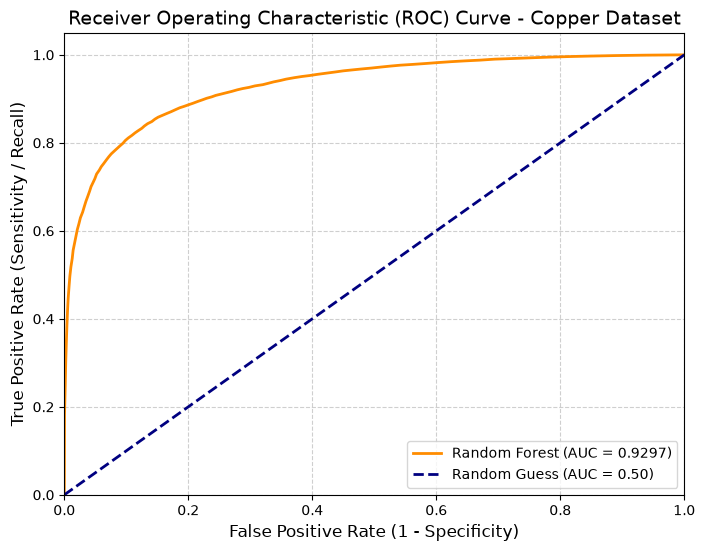

In [71]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curves_data["Random Forest Classifier"]
rf_auc = 0.9297

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {rf_auc:.4f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Copper Dataset', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

In [75]:
import pickle

best_idx = r2_list.index(max(r2_list))
best_model_name = model_list[best_idx]
best_reg_model = models[best_model_name]

print(f"Best regression model: {best_model_name} (R2 = {r2_list[best_idx]:.4f})")

with open("best_regression_model.pkl", "wb") as f:
    pickle.dump(best_reg_model, f)

print("Saved best_regression_model.pkl")

Best regression model: K-Neighbours Classifier (R2 = 0.5370)
Saved best_regression_model.pkl


In [76]:
best_idx = f1_macro_list.index(max(f1_macro_list))
best_model_name = model_list[best_idx]
best_clf_model = models[best_model_name]

print(f"Best classification model: {best_model_name} (score = {f1_macro_list[best_idx]:.4f})")

with open("best_classification_model.pkl", "wb") as f:
    pickle.dump(best_clf_model, f)

Best classification model: Random Forest Classifier (score = 0.9292)


In [77]:
# --- Add this as a new cell in your notebook, after the cells that pickle
#     best_reg_model and best_clf_model, then run it. ---
import pickle, os
# 
os.makedirs("source", exist_ok=True)

artifacts = {
    "item_encoder": item_encoder,              # OrdinalEncoder fit on grouped 'item type'
    "status_encoder": status_encoder,           # OrdinalEncoder fit on 'status'
    "app_country_encoder": encoder,             # OrdinalEncoder fit on ['application','country'], in that column order
    "reg_scaler": scaler,                       # StandardScaler used for the regression X
    "clf_scaler": scalar,                       # StandardScaler used for the classification X1
    "material_ref_target_mean": target_mean,    # pandas Series: cleaned material_ref -> train-only mean selling_price
    "material_ref_global_mean": global_mean,    # fallback for unseen/blank material_ref
    "reg_feature_order": list(X.columns),       # exact column order the regression model expects
    "clf_feature_order": list(X1.columns),      # exact column order the classification model expects
}

with open("source/artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

with open("source/best_regression_model.pkl", "wb") as f:
    pickle.dump(best_reg_model, f)

with open("source/best_classification_model.pkl", "wb") as f:
    pickle.dump(best_clf_model, f)

print("Saved source/artifacts.pkl, source/best_regression_model.pkl, source/best_classification_model.pkl")

Saved source/artifacts.pkl, source/best_regression_model.pkl, source/best_classification_model.pkl
